## Tugas 9 - Predicting Power Consumption using Linear Regression - Supervised Learning

> Download dataset (train_energy_data.csv dan test_energy_data.csv) disini : https://www.kaggle.com/datasets/govindaramsriram/energy-consumption-dataset-linear-regression?select=test_energy_data.csv

> Dataset merupakan data konsumsi daya berdasarkan banyak variabel lainnya.

> Dataset udah di-split menjadi: ``` train_energy_data.csv ``` dan ``` test_energy_data.csv ```

> Isi insight menggunakan bahasa sendiri dan bukan AI - generated.

> Deadline : 31 Oktober 2025.


---

Nama lengkap : Muhammad Zaenal Abidin Abdurrahman

Asal universitas : Telkom University

Program : AI Development

---


### 0. Import Module yang diperlukan

> Import module yang diperlukan untuk mendukung seluruh kegiatan

In [1]:
# Core data handling
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Machine learning utilities
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="deep")

RANDOM_STATE = 42


### 1. Problem Identification

> Jelaskan permasalahan yang ingin diselesaikan dari dataset ini. Contoh: "Bagaimana memprediksi konsumsi energi bangunan berdasarkan karakteristik bangunan dan lingkungan sekitar."

The main problem is to build a supervised regression model that can predict building energy consumption from building characteristics and environmental context.

In this dataset, the target variable is `Energy Consumption`, while the predictor variables include building type, square footage, number of occupants, appliances used, average temperature, and day category. A reliable model can help estimate expected power consumption before the actual value is observed.


### 2. Data Collection

> Di sini silakan muat data dan menuliskan deskripsi awal.

In [2]:
def find_dataset(file_name):
    """Locate the dataset in a local workspace or a typical Google Colab directory."""
    search_dirs = [Path.cwd(), Path("/content"), Path.cwd() / "data"]

    for directory in search_dirs:
        candidate = directory / file_name
        if candidate.exists():
            return candidate

    raise FileNotFoundError(
        f"{file_name} was not found. Place it in the notebook directory or /content."
    )


def readable_path(path):
    """Show relative paths when possible so notebook outputs stay portable."""
    try:
        return path.relative_to(Path.cwd())
    except ValueError:
        return path


train_path = find_dataset("train_energy_data.csv")
test_path = find_dataset("test_energy_data.csv")

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print(f"Training dataset path: {readable_path(train_path)}")
print(f"Testing dataset path : {readable_path(test_path)}")

dataset_summary = pd.DataFrame(
    {
        "Dataset": ["Training", "Testing"],
        "Rows": [df_train.shape[0], df_test.shape[0]],
        "Columns": [df_train.shape[1], df_test.shape[1]],
    }
)

display(dataset_summary)

print("Training data preview")
display(df_train.head())

print("Testing data preview")
display(df_test.head())

print("Column data types")
display(
    pd.concat(
        [df_train.dtypes.rename("Training dtype"), df_test.dtypes.rename("Testing dtype")],
        axis=1,
    )
)


Training dataset path: train_energy_data.csv
Testing dataset path : test_energy_data.csv
Training data preview
Testing data preview
Column data types


,Dataset,Rows,Columns
0,Training,1000,7
1,Testing,100,7


,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,24563,15,4,28.52,Weekday,2865.57
1,Commercial,27583,56,23,23.07,Weekend,4283.80
2,Commercial,45313,4,44,33.56,Weekday,5067.83
3,Residential,41625,84,17,27.39,Weekend,4624.30
4,Residential,36720,58,47,17.08,Weekday,4820.59


,Training dtype,Testing dtype
Building Type,object,object
Square Footage,int64,int64
Number of Occupants,int64,int64
Appliances Used,int64,int64
Average Temperature,float64,float64
Day of Week,object,object
Energy Consumption,float64,float64


**Insight:** The training set contains 1,000 rows and the testing set contains 100 rows. Both files use the same seven columns, so the test data can be evaluated directly after training. The target column is `Energy Consumption`, and the predictors contain a mix of numerical variables and categorical variables that need encoding before being passed into a regression model.


### 3. Data Preprocessing

> Tahapan membersihkan data dan menangani data yang hilang atau rusak. Gunakan metode yang diperlukan.

In [3]:
TARGET = "Energy Consumption"

if TARGET not in df_train.columns:
    raise ValueError(f"Target column `{TARGET}` was not found in the training dataset.")

feature_columns = [column for column in df_train.columns if column != TARGET]

X = df_train[feature_columns].copy()
y = df_train[TARGET].copy()
X_test = df_test[feature_columns].copy()
y_test = df_test[TARGET].copy() if TARGET in df_test.columns else None

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

quality_report = pd.DataFrame(
    {
        "training_missing": df_train.isna().sum(),
        "testing_missing": df_test.isna().sum(),
        "training_dtype": df_train.dtypes.astype(str),
        "testing_dtype": df_test.dtypes.astype(str),
    }
)

display(quality_report)

print(f"Training duplicate rows: {df_train.duplicated().sum()}")
print(f"Testing duplicate rows : {df_test.duplicated().sum()}")
print(f"Numerical features     : {numeric_features}")
print(f"Categorical features   : {categorical_features}")

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


Training duplicate rows: 0
Testing duplicate rows : 0
Numerical features     : ['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature']
Categorical features   : ['Building Type', 'Day of Week']


,training_missing,testing_missing,training_dtype,testing_dtype
Building Type,0,0,object,object
Square Footage,0,0,int64,int64
Number of Occupants,0,0,int64,int64
Appliances Used,0,0,int64,int64
Average Temperature,0,0,float64,float64
Day of Week,0,0,object,object
Energy Consumption,0,0,float64,float64


**Insight:** No missing values and no exact duplicate rows were found in either dataset. Even though the current data is already clean, the modeling pipeline still includes imputers, scaling, and one-hot encoding. This makes the workflow safer if a future batch of data contains missing values or uses the same categorical columns with a different distribution.


### 4. EDA dan Visualisasi Data

> Menjelajahi data secara mendalam untuk mencari pola dan hubungan antar variabel.

Descriptive statistics
Average energy consumption by Building Type
Average energy consumption by Day of Week


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Building Type,1000,3,Residential,347,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Square Footage,1000.0,NaN,NaN,NaN,25462.388,14294.554,560.0,13169.75,25477.0,37446.25,49997.0
Number of Occupants,1000.0,NaN,NaN,NaN,48.372,29.061972,1.0,22.0,47.0,73.25,99.0
Appliances Used,1000.0,NaN,NaN,NaN,25.606,14.105166,1.0,13.0,26.0,38.0,49.0
Average Temperature,1000.0,NaN,NaN,NaN,22.61139,7.139943,10.05,16.475,22.815,28.85,34.99
Day of Week,1000,2,Weekday,507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Energy Consumption,1000.0,NaN,NaN,NaN,4166.25257,933.313064,1683.95,3509.4825,4175.73,4863.85,6530.6


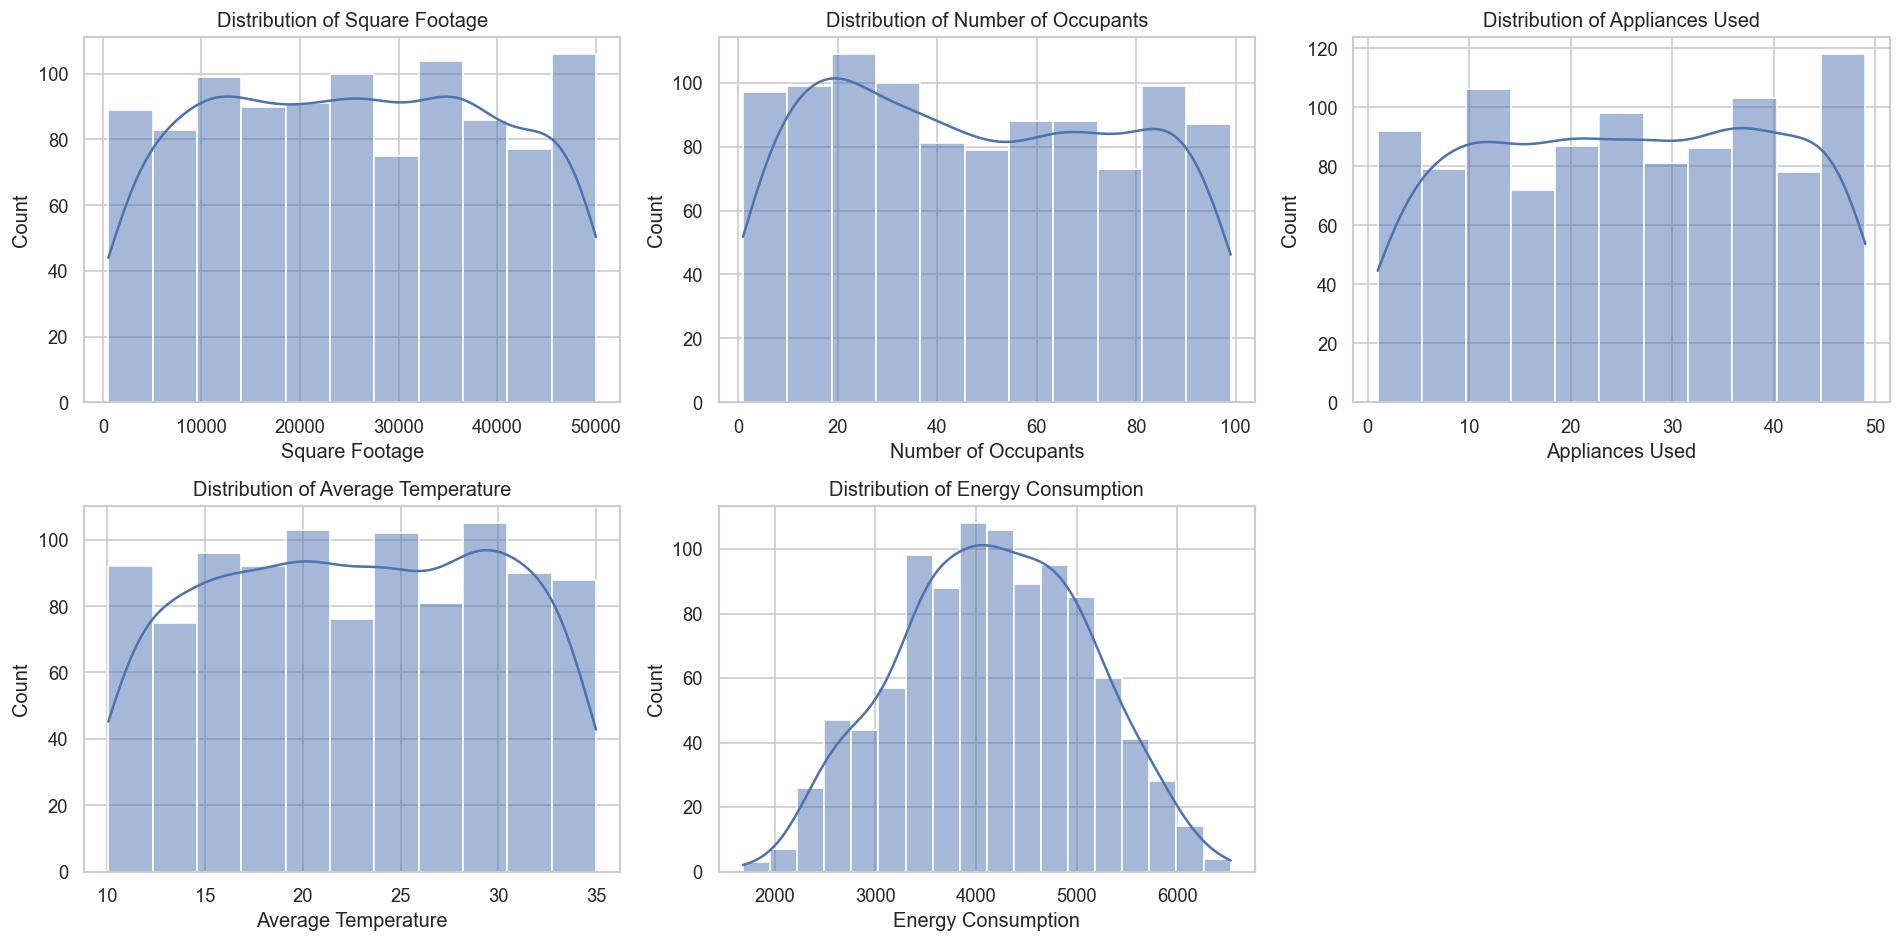

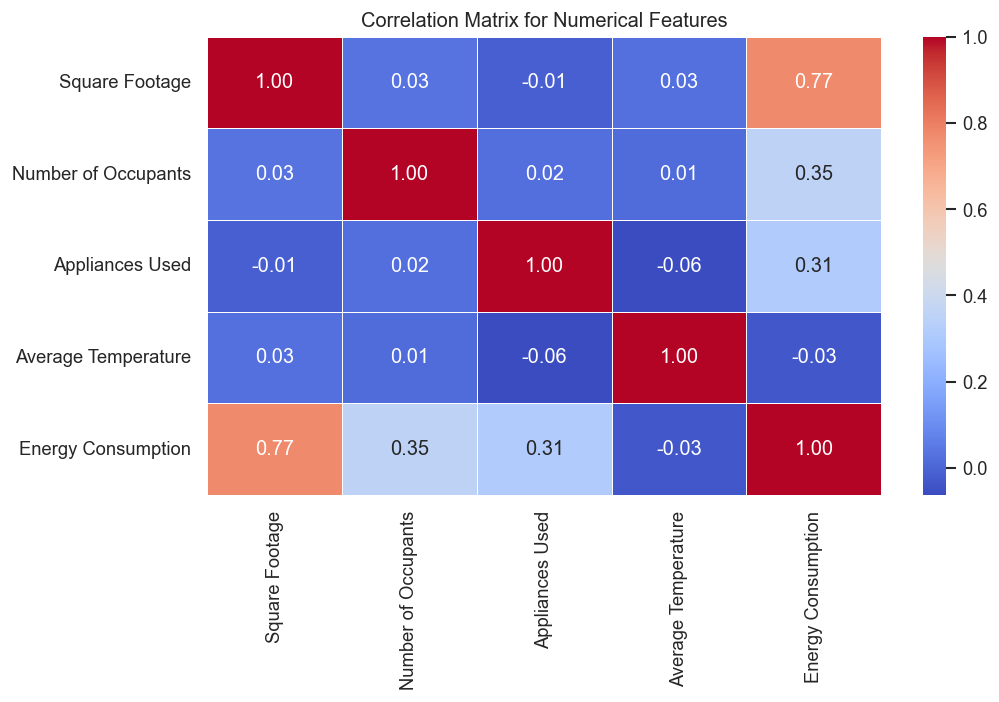

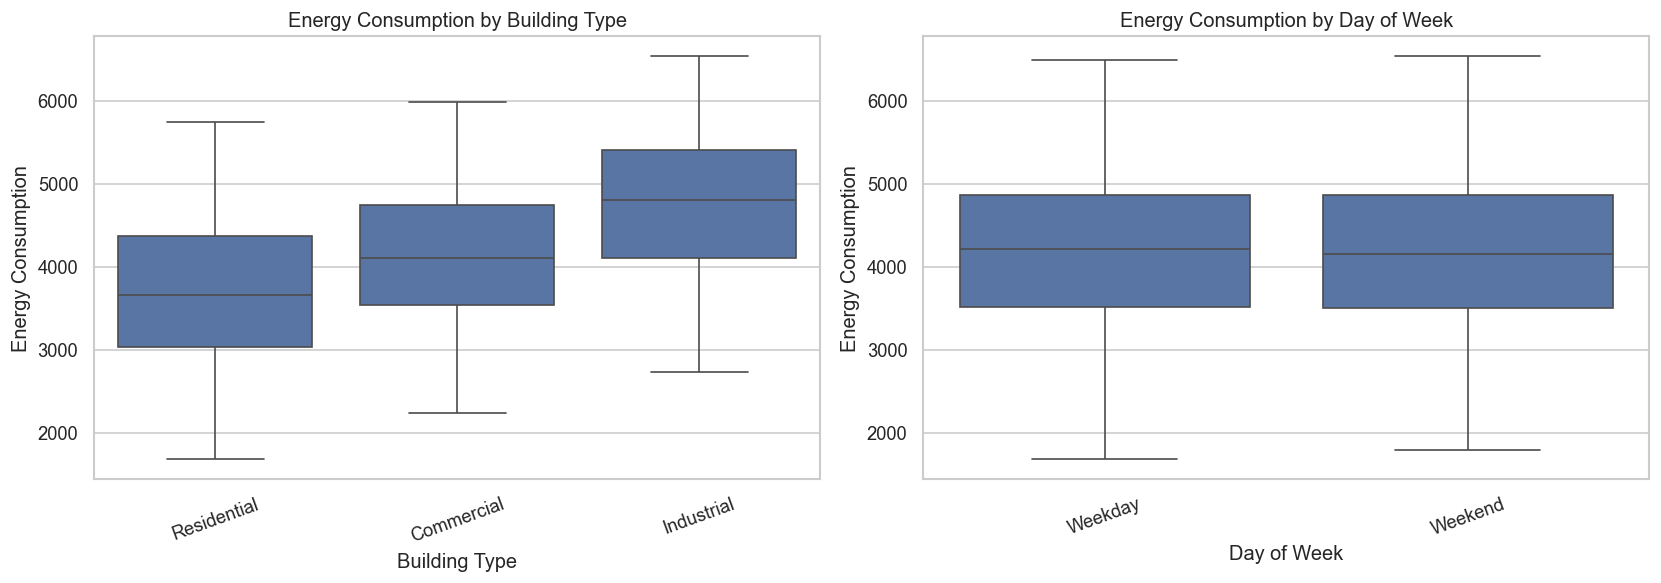

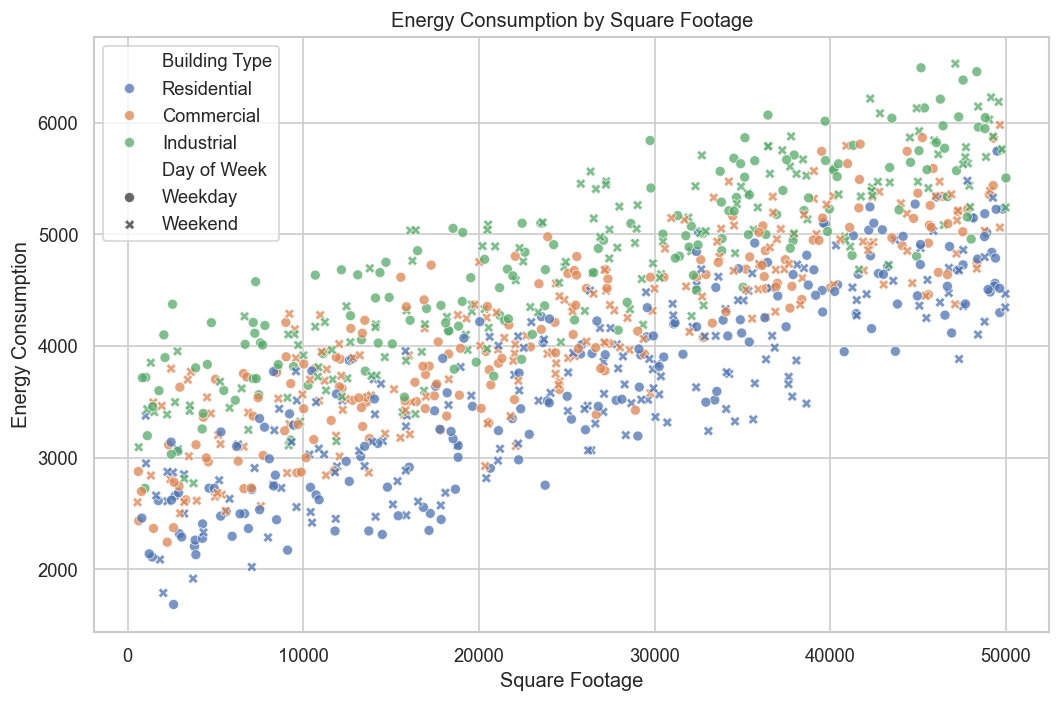

,count,mean,median,std
Building Type,,,,
Industrial,317,4735.142618,4805.220,829.406280
Commercial,336,4130.023571,4108.895,809.836992
Residential,347,3681.626628,3661.210,847.616993


,count,mean,median,std
Day of Week,,,,
Weekday,507,4170.293491,4209.18,955.942139
Weekend,493,4162.096897,4149.86,910.407051


In [4]:
print("Descriptive statistics")
display(df_train.describe(include="all").T)

numeric_columns_for_plot = numeric_features + [TARGET]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for index, column in enumerate(numeric_columns_for_plot):
    sns.histplot(df_train[column], kde=True, ax=axes[index])
    axes[index].set_title(f"Distribution of {column}")

for axis in axes[len(numeric_columns_for_plot):]:
    axis.axis("off")

plt.tight_layout()
plt.show()

correlation_matrix = df_train[numeric_columns_for_plot].corr()
plt.figure(figsize=(9, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix for Numerical Features")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for axis, column in zip(axes, categorical_features):
    sns.boxplot(data=df_train, x=column, y=TARGET, ax=axis)
    axis.set_title(f"{TARGET} by {column}")
    axis.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_train,
    x="Square Footage",
    y=TARGET,
    hue="Building Type",
    style="Day of Week",
    alpha=0.75,
)
plt.title("Energy Consumption by Square Footage")
plt.tight_layout()
plt.show()

for column in categorical_features:
    print(f"Average energy consumption by {column}")
    display(
        df_train.groupby(column)[TARGET]
        .agg(["count", "mean", "median", "std"])
        .sort_values("mean", ascending=False)
    )


**Insight:** `Square Footage` has the strongest visible relationship with `Energy Consumption`, followed by operational features such as `Number of Occupants` and `Appliances Used`. The categorical plots show that industrial buildings tend to consume more energy, while residential buildings tend to consume less. Weekday and weekend values are close, but the model should still keep `Day of Week` because even a small systematic difference can improve prediction accuracy.


### 5. Pembangunan Model Regresi Linear dan Evaluasi Model

> Latih model menggunakan data yang sudah bersih dan lakukan evaluasi.

In [5]:
def regression_metrics(y_true, y_pred):
    """Return common regression metrics in a compact dictionary."""
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

model_candidates = {
    "Dummy Mean Baseline": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=RANDOM_STATE),
}

evaluation_rows = []
validation_pipelines = {}

for model_name, estimator in model_candidates.items():
    pipeline = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", clone(estimator)),
        ]
    )
    pipeline.fit(X_train, y_train)
    validation_prediction = pipeline.predict(X_valid)
    metrics = regression_metrics(y_valid, validation_prediction)

    validation_pipelines[model_name] = pipeline
    evaluation_rows.append({"Model": model_name, **metrics})

validation_results = pd.DataFrame(evaluation_rows).sort_values("RMSE").reset_index(drop=True)
display(validation_results)

best_model_name = validation_results.loc[0, "Model"]
print(f"Best validation model: {best_model_name}")

final_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", clone(model_candidates[best_model_name])),
    ]
)
final_model.fit(X, y)

if y_test is not None:
    test_prediction = final_model.predict(X_test)
    test_results = pd.DataFrame(
        [{"Model": best_model_name, **regression_metrics(y_test, test_prediction)}]
    )
    display(test_results)

raw_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)),
                ]
            ),
            categorical_features,
        ),
    ]
)

coefficient_model = Pipeline(
    steps=[
        ("preprocess", raw_preprocessor),
        ("model", LinearRegression()),
    ]
)
coefficient_model.fit(X, y)

encoder = coefficient_model.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
encoded_feature_names = encoder.get_feature_names_out(categorical_features)
model_feature_names = numeric_features + encoded_feature_names.tolist()

coefficient_table = (
    pd.DataFrame(
        {
            "Feature": model_feature_names,
            "Coefficient": coefficient_model.named_steps["model"].coef_,
        }
    )
    .assign(Absolute_Coefficient=lambda data: data["Coefficient"].abs())
    .sort_values("Absolute_Coefficient", ascending=False)
    .drop(columns="Absolute_Coefficient")
)

reference_levels = pd.DataFrame(
    {
        "Categorical Feature": categorical_features,
        "Reference Level": [categories[0] for categories in encoder.categories_],
    }
)

print("Linear model coefficients using original feature scale")
display(coefficient_table)

print("Reference levels for one-hot encoded categorical features")
display(reference_levels)


Best validation model: Linear Regression
Linear model coefficients using original feature scale
Reference levels for one-hot encoded categorical features


,Model,MAE,RMSE,R2
0,Linear Regression,0.011412,0.013731,1.000000
1,Ridge Regression,1.504407,1.828498,0.999996
2,Dummy Mean Baseline,737.988380,907.010064,-0.010275


,Model,MAE,RMSE,R2
0,Linear Regression,0.012162,0.014197,1.0


,Feature,Coefficient
4,Building Type_Industrial,500.000492
5,Building Type_Residential,-500.000189
6,Day of Week_Weekend,-50.000770
2,Appliances Used,20.000020
1,Number of Occupants,10.000003
3,Average Temperature,-5.000047
0,Square Footage,0.050000


,Categorical Feature,Reference Level
0,Building Type,Commercial
1,Day of Week,Weekday


**Insight:** Linear Regression performs far better than the dummy baseline and slightly better than Ridge on this dataset. The validation and test scores are almost perfect, which strongly suggests that the dataset follows a clean linear data-generating pattern. This is useful for learning Linear Regression, but it should not be overinterpreted as a guarantee that real building-energy data would be this predictable.


### 6. Simpan model dan scaler

In [6]:
MODEL_PATH = Path("energy_consumption_linear_pipeline.joblib")

joblib.dump(final_model, MODEL_PATH)

print(f"Saved model pipeline to: {MODEL_PATH}")
print("The saved pipeline includes preprocessing steps, the scaler, encoders, and the trained model.")


Saved model pipeline to: energy_consumption_linear_pipeline.joblib
The saved pipeline includes preprocessing steps, the scaler, encoders, and the trained model.


### 7. Prediksi Data Baru dan Kesimpulan Akhir

> Coba prediksi data baru yang diinput manual oleh user.

In [7]:
loaded_model = joblib.load(MODEL_PATH)

sample_input = pd.DataFrame(
    [
        {
            "Building Type": "Commercial",
            "Square Footage": 30000,
            "Number of Occupants": 45,
            "Appliances Used": 25,
            "Average Temperature": 24.0,
            "Day of Week": "Weekday",
        }
    ]
)

sample_prediction = loaded_model.predict(sample_input)[0]

sample_output = sample_input.copy()
sample_output["Predicted Energy Consumption"] = round(sample_prediction, 2)

display(sample_output)

if y_test is not None:
    prediction_preview = X_test.head(5).copy()
    prediction_preview["Actual Energy Consumption"] = y_test.head(5).to_numpy()
    prediction_preview["Predicted Energy Consumption"] = loaded_model.predict(X_test.head(5)).round(2)
    prediction_preview["Absolute Error"] = (
        prediction_preview["Actual Energy Consumption"]
        - prediction_preview["Predicted Energy Consumption"]
    ).abs().round(2)

    display(prediction_preview)


,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Predicted Energy Consumption
0,Commercial,30000,45,25,24.0,Weekday,4380.0


,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Actual Energy Consumption,Predicted Energy Consumption,Absolute Error
0,Residential,24563,15,4,28.52,Weekday,2865.57,2865.55,0.02
1,Commercial,27583,56,23,23.07,Weekend,4283.80,4283.80,0.00
2,Commercial,45313,4,44,33.56,Weekday,5067.83,5067.85,0.02
3,Residential,41625,84,17,27.39,Weekend,4624.30,4624.30,0.00
4,Residential,36720,58,47,17.08,Weekday,4820.59,4820.60,0.01


### 8. Kesimpulan Project:

> Berikan kesimpulan untuk project ini.

The project successfully builds a supervised regression workflow for predicting building energy consumption. The final pipeline loads the dataset, audits data quality, preprocesses numerical and categorical features, trains regression models, evaluates them against a baseline, saves the complete model pipeline, and demonstrates prediction on new input data.

The best model is Linear Regression. It achieves near-perfect validation and test performance because the dataset appears to follow a highly linear pattern. The most influential predictors are square footage, building type, number of occupants, appliances used, average temperature, and day category. In a real production setting, the next improvement would be validating the model on more realistic data collected from actual buildings over time.
